In [1]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

In [3]:
from apps.onpe.schemas import ConsultaElectoral
from apps.onpe.enums import Eleccion, AmbitoGeografico, UbigeoNivel1, TipoFiltro
import requests
from pydantic import BaseModel, computed_field, ConfigDict, Field, model_validator
from typing import Annotated, Self, Literal
from apps.onpe.client import get_resultados_onpe
import math
from apps.onpe.client import cookies, headers

In [88]:
def obtener_proyeccion_por_ubigeo(
    eleccion: Eleccion, ubigeo_list: List[UbigeoNivel1]
) -> pd.DataFrame:
    """
    Obtiene datos de cada ubigeo y calcula la proyección al 100%

    La fórmula es: Proyección = Total Votos Válidos Actuales / (Porcentaje de Actas / 100)
    """
    resultados = []

    for ubigeo in ubigeo_list:
        try:
            # Crear consulta
            consulta = ConsultaElectoral(eleccion=eleccion, ubigeo=ubigeo)

            # Obtener datos
            data_resumen = get_resultados_onpe(consulta, mode="resumen")["data"]
            data_detalle = get_resultados_onpe(consulta, mode="detalle")["data"]

            porcentaje_actas = data_resumen["actasContabilizadas"]

            # Procesar cada candidato
            for data in data_detalle:
                votos_actuales = data["totalVotosValidos"]

                # Calcular proyección al 100%
                if porcentaje_actas > 0:
                    proyeccion = int(votos_actuales / porcentaje_actas * 100)

                resultados.append(
                    {
                        "ubigeo": ubigeo.name,
                        "candidato": data["nombreAgrupacionPolitica"],
                        "votos_actuales": votos_actuales,
                        "proyeccion": proyeccion,
                    }
                )
        except Exception as e:
            print(f"Error procesando {ubigeo.name}: {str(e)}")
            continue

    return pd.DataFrame(resultados)


# Obtener lista de ubigeos válidos para elecciones presidenciales
ubigeos_validos_presidencial = [
    ubigeo
    for ubigeo in list(UbigeoNivel1)
    if ubigeo
    not in [
        UbigeoNivel1.LIMA_METROPOLITANA,
        UbigeoNivel1.LIMA_PROVINCIAS,
        UbigeoNivel1.PERUANOS_RESIDENTES_EN_EL_EXTRANJERO,
        UbigeoNivel1.AFRICA
    ]
]

print(f"Obteniendo proyecciones para {len(ubigeos_validos_presidencial)} ubigeos...")
print("Esto puede tomar algunos minutos...")

# Obtener datos
df_proyecciones = obtener_proyeccion_por_ubigeo(
    Eleccion.PRESIDENCIAL, ubigeos_validos_presidencial
)

print(f"✓ Datos procesados: {len(df_proyecciones)} registros")
print(f"✓ Ubigeos procesados: {df_proyecciones['ubigeo'].nunique()}")

Obteniendo proyecciones para 29 ubigeos...
Esto puede tomar algunos minutos...
✓ Datos procesados: 1102 registros
✓ Ubigeos procesados: 29


In [95]:
df_proyecciones

,ubigeo,candidato,votos_actuales,proyeccion
0,AMAZONAS,JUNTOS POR EL PERÚ,31729,54138
1,AMAZONAS,VOTOS EN BLANCO,22182,37848
2,AMAZONAS,FUERZA POPULAR,20733,35376
3,AMAZONAS,PARTIDO CÍVICO OBRAS,12326,21031
4,AMAZONAS,VOTOS NULOS,9560,16312
...,...,...,...,...
1097,OCEANIA,UN CAMINO DIFERENTE,0,0
1098,OCEANIA,PERÚ MODERNO,0,0
1099,OCEANIA,SALVEMOS AL PERÚ,0,0
1100,OCEANIA,PARTIDO DEMÓCRATA UNIDO PERÚ,0,0


1er puesto proyectado: FUERZA POPULAR (14.35%)
2do puesto proyectado: VOTOS EN BLANCO (11.42%)
Brecha del 2do vs 1ro: 2.93 puntos porcentuales


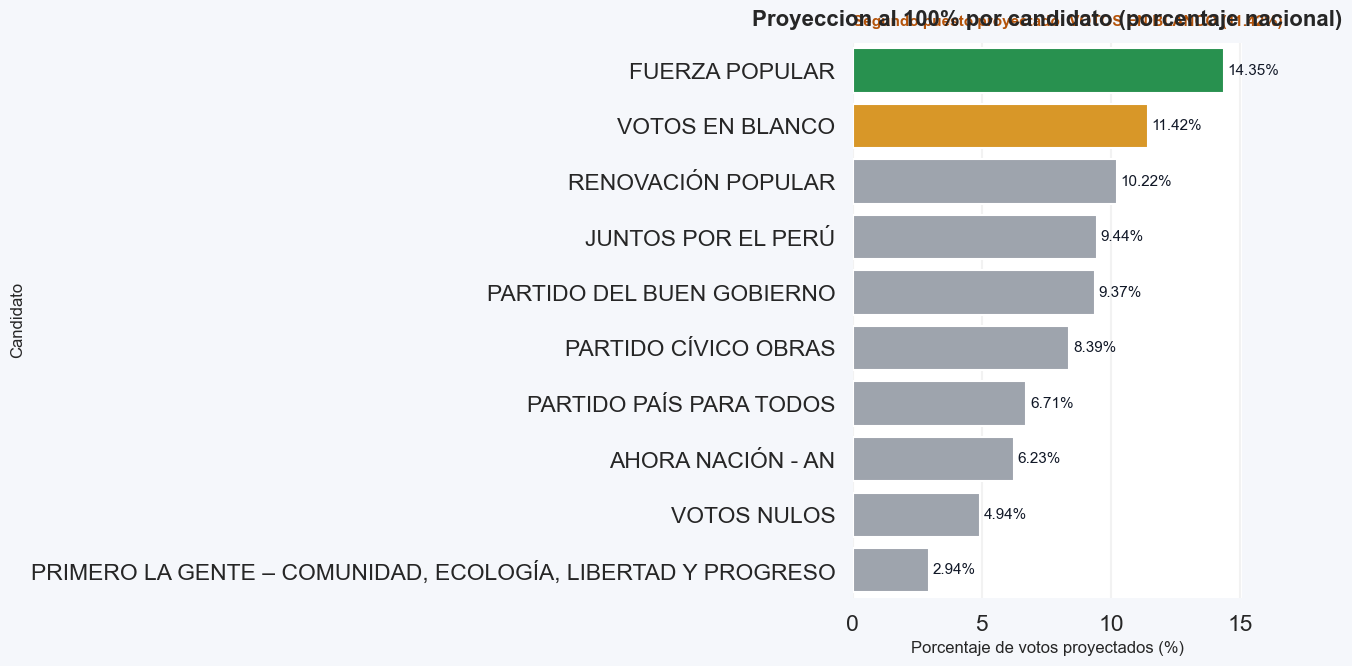

In [ ]:
# Analisis principal: segundo puesto proyectado con porcentajes y votos totales
base = df_proyecciones.copy()
base['proyeccion'] = pd.to_numeric(base['proyeccion'], errors='coerce')
base = base.dropna(subset=['candidato', 'proyeccion'])

if base.empty:
    print('No hay datos suficientes para calcular la proyeccion.')
else:
    resumen = (
        base.groupby('candidato', as_index=False)['proyeccion']
        .sum()
        .sort_values('proyeccion', ascending=False)
        .reset_index(drop=True)
    )

    total = int(resumen['proyeccion'].sum())
    resumen['porcentaje'] = (resumen['proyeccion'] / total * 100).round(2)

    if len(resumen) < 2:
        print('Solo hay un candidato en los datos; no se puede calcular segundo puesto.')
    else:
        primero = resumen.iloc[0]
        segundo = resumen.iloc[1]
        brecha_pp = round(primero['porcentaje'] - segundo['porcentaje'], 2)

        print(f"Votos totales proyectados: {total:,}".replace(',', '.'))
        print(
            f"1er puesto proyectado: {primero['candidato']} "
            f"({primero['porcentaje']:.2f}% | {int(primero['proyeccion']):,} votos)".replace(',', '.')
        )
        print(
            f"2do puesto proyectado: {segundo['candidato']} "
            f"({segundo['porcentaje']:.2f}% | {int(segundo['proyeccion']):,} votos)".replace(',', '.')
        )
        print(f"Brecha del 2do vs 1ro: {brecha_pp:.2f} puntos porcentuales")

        # Grafico principal con enfoque en porcentaje y segundo puesto
        top_n = min(10, len(resumen))
        plot_df = resumen.head(top_n).copy()

        colors = ['#9ca3af'] * len(plot_df)
        colors[0] = '#16a34a'  # primer puesto
        colors[1] = '#f59e0b'  # segundo puesto

        plt.figure(figsize=(13, 7), facecolor='#f5f7fb')
        ax = sns.barplot(
            data=plot_df,
            x='porcentaje',
            y='candidato',
            palette=colors
        )

        for i, row in plot_df.iterrows():
            etiqueta = f"{row['porcentaje']:.2f}% | {int(row['proyeccion']):,} votos".replace(',', '.')
            ax.text(
                row['porcentaje'] + 0.18,
                i,
                etiqueta,
                va='center',
                fontsize=10,
                color='#111827'
            )

        ax.set_title('Proyeccion al 100% por candidato (porcentaje nacional)', fontsize=16, weight='bold', pad=12)
        ax.set_xlabel('Porcentaje de votos proyectados (%)', fontsize=12)
        ax.set_ylabel('Candidato', fontsize=12)
        ax.grid(axis='x', alpha=0.25)
        sns.despine(left=True, bottom=True)

        subtitulo = (
            f"Segundo puesto proyectado: {segundo['candidato']} "
            f"({segundo['porcentaje']:.2f}% | {int(segundo['proyeccion']):,} votos)".replace(',', '.')
        )
        ax.text(
            0,
            1.03,
            subtitulo,
            transform=ax.transAxes,
            fontsize=11,
            color='#b45309',
            weight='bold'
        )

        plt.tight_layout()
        plt.show()